# Experiment 07: Range Bound 3 Layer Network

In this experiment we prototype a function for range
bounding a 3 layer network.


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from prism.networks.ffnn3 import FFNN3

from verified_computing import intvmath
from verified_computing import taylorfactory

## Construct Taylor Models

Here we begin by building Taylor models for our activations.


<class 'matplotlib.axes._subplots.AxesSubplot'>
Min and max error:
[-0.07136968] [0.07136968]
<class 'matplotlib.axes._subplots.AxesSubplot'>
Min and max error:
[-0.04264607] [0.04264607]
<class 'matplotlib.axes._subplots.AxesSubplot'>
Min and max error:
[-0.15005211] [0.05119388]


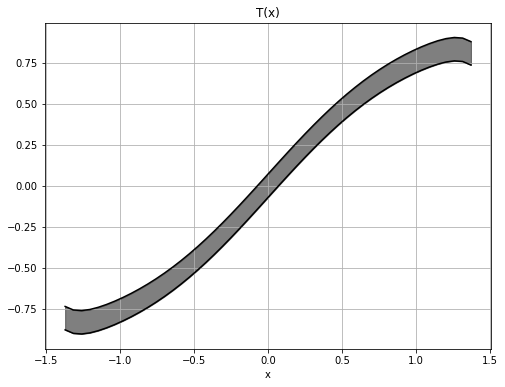

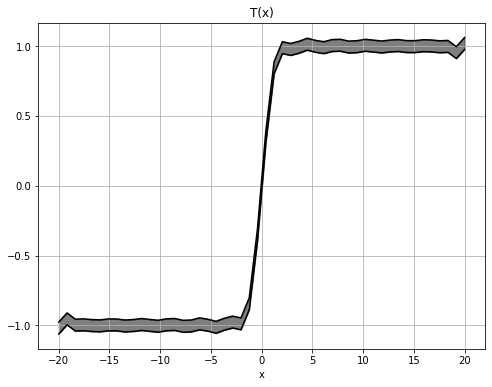

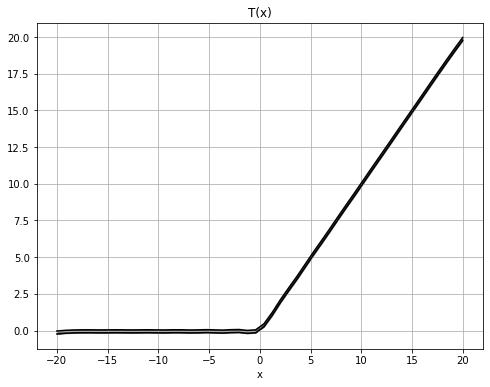

In [3]:
bound = np.pi/2 - 0.2
big_m = 8

# Tanh Taylor model with Taylor polynomials
t_tanh_taylor = taylorfactory.get_taylor_model(
    function_type='tanh_taylor',
    big_m=big_m,
    v_max=bound,
    dps=100,
    silent=True,
    n_brute_points=100,
    tol_final=1e-3
)

t_tanh_taylor.plot(x_min=-bound, x_max=bound)
print('Min and max error:')
print(t_tanh_taylor.error.x1, t_tanh_taylor.error.x2)

big_m = 55
bound = 20
dps = 300

# Tanh Taylor model with AMIE polynomials
t_tanh_amie = taylorfactory.get_taylor_model(
    function_type='tanh',
    big_m=big_m,
    v_max=bound,
    dps=dps,
    silent=True,
    n_brute_points=100,
    tol_final=1e-3
)

t_tanh_amie.plot(x_min=-bound, x_max=bound)
print('Min and max error:')
print(t_tanh_amie.error.x1, t_tanh_amie.error.x2)

# ReLU Taylor model with AMIE polynomials
t_relu_amie = taylorfactory.get_taylor_model(
    function_type='relu',
    big_m=big_m,
    v_max=bound,
    dps=dps,
    silent=True,
    n_brute_points=100,
    tol_final=1e-3
)

t_relu_amie.plot(x_min=-bound, x_max=bound)
print('Min and max error:')
print(t_relu_amie.error.x1, t_relu_amie.error.x2)

## Create and Train a Neural Network

In [35]:
weight_decay = 0.01

relu_net = FFNN3(
    net_type='relu',
    n_inputs=2, n_hidden=(500,500,500), lr=0.01, momentum=0.1,
    rho=0.9, eps=1e-06, betas=(0.9, 0.99),
    use_gpu=True, optimizer_method='adam',
    weight_decay=weight_decay)

tanh_net = FFNN3(
    net_type='tanh',
    n_inputs=2, n_hidden=(500,500,500), lr=0.01, momentum=0.1,
    rho=0.9, eps=1e-06, betas=(0.9, 0.99),
    use_gpu=True, optimizer_method='adam',
    weight_decay=weight_decay)


## Define Range Bounding Functions

Here we define functions for range bounding:
* numerically
* tanh via taylor
* tanh via AMIE
* relu via AMIE

In [36]:
def range_bound_ffnn3_numerical(net, x_min, x_max, n_points):
    """Range bound an FFNN3 instance numerically"""
    x_domain = np.random.uniform(
        low=x_min, high=x_max,
        size=(n_points, net.n_inputs))
    y_range = net.infer(x_domain)
    y_min = np.min(y_range)
    y_max = np.max(y_range)
    return y_min, y_max


In [37]:
def range_bound_ffnn3_taylor_model(
        net, taylor_model, x_min, x_max, n_subdomains
):
    """Range bound an FFNN3 instance via AMIE polynomials"""
    # Input Intervals
    x = intvmath.IntervalColumnVector(
        [intvmath.Interval(x_min, x_max)] * net.n_inputs
    )

    # Layer 1
    b1 = net.get_b1()
    w1 = net.get_w1()

    w_times_x = intvmath.left_multiply_interval_column_vector_by_matrix(
        w1, x
    )

    v = intvmath.add_real_vector_to_interval_column_vector(b1, w_times_x)

    x = taylor_model.bound_interval_vector(v, n_subdomains=n_subdomains)

    # Layer 2
    b2 = net.get_b2()
    w2 = net.get_w2()

    w_times_x = intvmath.left_multiply_interval_column_vector_by_matrix(
        w2, x
    )

    v = intvmath.add_real_vector_to_interval_column_vector(b2, w_times_x)

    x = taylor_model.bound_interval_vector(v, n_subdomains=n_subdomains)

    # Layer 3
    b3 = net.get_b3()
    w3 = net.get_w3()

    w_times_x = intvmath.left_multiply_interval_column_vector_by_matrix(
        w3, x
    )

    v = intvmath.add_real_vector_to_interval_column_vector(b3, w_times_x)

    x = taylor_model.bound_interval_vector(v, n_subdomains=n_subdomains)

    # Layer 4
    b4 = net.get_b4()
    w4 = net.get_w4()

    w_times_x = intvmath.left_multiply_interval_column_vector_by_matrix(
        w4, x
    )

    y = intvmath.add_real_vector_to_interval_column_vector(b4, w_times_x)

    return y.elems[0].x1, y.elems[0].x2


In [38]:
x_min = -0.3
x_max = 0.3

n_subdomains = 50

# Tanh Bounding
range_min, range_max = range_bound_ffnn3_numerical(
    tanh_net, x_min, x_max, 10000)
print('Tanh net numerical bounds:')
print(range_min, range_max)

range_min, range_max = range_bound_ffnn3_taylor_model(
    tanh_net, t_tanh_amie, x_min, x_max, n_subdomains)
print('Tanh net AMIE bounds:')
print(range_min, range_max)

range_min, range_max = range_bound_ffnn3_taylor_model(
    tanh_net, t_tanh_taylor, x_min, x_max, n_subdomains)
print('Tanh net Taylor bounds:')
print(range_min, range_max)

# ReLU bounding
range_min, range_max = range_bound_ffnn3_numerical(
    relu_net, x_min, x_max, 10000)
print('ReLU net numerical bounds:')
print(range_min, range_max)

range_min, range_max = range_bound_ffnn3_taylor_model(
    relu_net, t_relu_amie, x_min, x_max, n_subdomains)
print('ReLU net AMIE bounds:')
print(range_min, range_max)


Tanh net numerical bounds:
-0.07842262 0.019702695


KeyboardInterrupt: 